Qn.2 Data Preparation

In [1]:
!pip install pandas
!pip install scipy

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
#Load the Dataset
df = pd.read_csv('network_traffic.csv')


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 488115 entries, 0 to 488114
Data columns (total 80 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   488115 non-null  int64  
 1   Destination Port             488115 non-null  int64  
 2   Flow Duration                488115 non-null  int64  
 3   Total Fwd Packets            488115 non-null  int64  
 4   Total Backward Packets       488115 non-null  int64  
 5   Total Length of Fwd Packets  488115 non-null  int64  
 6   Total Length of Bwd Packets  488115 non-null  int64  
 7   Fwd Packet Length Max        488115 non-null  int64  
 8   Fwd Packet Length Min        488115 non-null  int64  
 9   Fwd Packet Length Mean       488115 non-null  float64
 10  Fwd Packet Length Std        488115 non-null  float64
 11  Bwd Packet Length Max        488115 non-null  int64  
 12  Bwd Packet Length Min        488115 non-null  int64  
 13  Bwd Packet

In [5]:
df

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,53,62171,2,2,78,164,39,39,39.00,...,32,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
1,1,2710,48,2,0,4,0,2,2,2.00,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,Infiltration
2,2,443,4792909,5,1,135,46,46,6,27.00,...,20,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
3,3,80,115596470,75,82,342,118155,342,0,4.56,...,32,22092.63636,22835.59127,90944,14999,10000000.0,2701.650839,10000000,9997164,BENIGN
4,4,2910,14,2,2,4,12,2,2,2.00,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488110,488110,53,238,2,2,86,228,43,43,43.00,...,32,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
488111,488111,8899,3,2,0,4,0,2,2,2.00,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,Infiltration
488112,488112,53,250,2,2,82,206,41,41,41.00,...,20,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
488113,488113,53,70581019,2,2,117,231,66,51,58.50,...,32,41306.00000,0.00000,41306,41306,70300000.0,0.000000,70300000,70300000,BENIGN


In [6]:
df = df.drop(columns=['Unnamed: 0'])

In [7]:
#Display First five records
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,62171,2,2,78,164,39,39,39.00,0.000000,...,32,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
1,2710,48,2,0,4,0,2,2,2.00,0.000000,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,Infiltration
2,443,4792909,5,1,135,46,46,6,27.00,20.124612,...,20,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN
3,80,115596470,75,82,342,118155,342,0,4.56,39.490758,...,32,22092.63636,22835.59127,90944,14999,10000000.0,2701.650839,10000000,9997164,BENIGN
4,2910,14,2,2,4,12,2,2,2.00,0.000000,...,24,0.00000,0.00000,0,0,0.0,0.000000,0,0,BENIGN


In [8]:
#Display last 50 Records
df.tail(50)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
488065,53,70591,2,2,66,194,33,33,33.000000,0.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration
488066,443,5572560,8,6,386,5205,205,0,48.250000,75.952523,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488067,3013,49,2,0,4,0,2,2,2.000000,0.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488068,53,122130,2,2,80,272,40,40,40.000000,0.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488069,53,98106274,2,2,114,211,58,56,57.000000,1.414214,...,20,30943.00000,0.00000,30943,30943,9.800000e+07,0.00000,98000000,98000000,Infiltration
488070,53,506,1,1,53,113,53,53,53.000000,0.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488071,53,3957631,2,2,120,260,79,41,60.000000,26.870058,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488072,9102,2,2,0,4,0,2,2,2.000000,0.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488073,2135,111,2,2,4,12,2,2,2.000000,0.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488074,1048,49,2,0,4,0,2,2,2.000000,0.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration


In [9]:
#Create a new dataframe 
columns = ['Destination Port', 'Flow Duration', 'Total Fwd Packets','Total Backward Packets',  'Total Length of Fwd Packets','Total Length of Bwd Packets','Fwd Packet Length Mean','Bwd Packet Length Mean',
        'Flow Bytes/s', 'Flow Packets/s','Packet Length Mean','Packet Length Std', 'Average Packet Size','Active Mean', 'Idle Mean', 'Label']
new_df = df[columns]

In [10]:
new_df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Label
0,53,62171,2,2,78,164,39.00,82.000000,3.892490e+03,64.338679,56.200000,23.552070,70.250000,0.00000,0.0,BENIGN
1,2710,48,2,0,4,0,2.00,0.000000,8.333333e+04,41666.666670,2.000000,0.000000,3.000000,0.00000,0.0,Infiltration
2,443,4792909,5,1,135,46,27.00,46.000000,3.776412e+01,1.251849,32.428571,18.866700,37.833333,0.00000,0.0,BENIGN
3,80,115596470,75,82,342,118155,4.56,1440.914634,1.025092e+03,1.358173,749.981013,946.124811,754.757962,22092.63636,10000000.0,BENIGN
4,2910,14,2,2,4,12,2.00,6.000000,1.142857e+06,285714.285700,3.600000,2.190890,4.500000,0.00000,0.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488110,53,238,2,2,86,228,43.00,114.000000,1.319328e+06,16806.722690,71.400000,38.888302,89.250000,0.00000,0.0,BENIGN
488111,8899,3,2,0,4,0,2.00,0.000000,1.333333e+06,666666.666700,2.000000,0.000000,3.000000,0.00000,0.0,Infiltration
488112,53,250,2,2,82,206,41.00,103.000000,1.152000e+06,16000.000000,65.800000,33.958799,82.250000,0.00000,0.0,BENIGN
488113,53,70581019,2,2,117,231,58.50,115.500000,4.930504e+00,0.056672,82.800000,30.817203,103.500000,41306.00000,70300000.0,BENIGN


In [11]:
#Checking Missing Values
new_df.isnull().sum()

Destination Port                0
Flow Duration                   0
Total Fwd Packets               0
Total Backward Packets          0
Total Length of Fwd Packets     0
Total Length of Bwd Packets     0
Fwd Packet Length Mean          0
Bwd Packet Length Mean          0
Flow Bytes/s                   36
Flow Packets/s                  0
Packet Length Mean              0
Packet Length Std               0
Average Packet Size             0
Active Mean                     0
Idle Mean                       0
Label                           0
dtype: int64

In [12]:
#Remove Missing values
new_df = new_df.dropna()
new_df.isnull().sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Mean         0
Bwd Packet Length Mean         0
Flow Bytes/s                   0
Flow Packets/s                 0
Packet Length Mean             0
Packet Length Std              0
Average Packet Size            0
Active Mean                    0
Idle Mean                      0
Label                          0
dtype: int64

In [13]:
new_df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Label
0,53,62171,2,2,78,164,39.00,82.000000,3.892490e+03,64.338679,56.200000,23.552070,70.250000,0.00000,0.0,BENIGN
1,2710,48,2,0,4,0,2.00,0.000000,8.333333e+04,41666.666670,2.000000,0.000000,3.000000,0.00000,0.0,Infiltration
2,443,4792909,5,1,135,46,27.00,46.000000,3.776412e+01,1.251849,32.428571,18.866700,37.833333,0.00000,0.0,BENIGN
3,80,115596470,75,82,342,118155,4.56,1440.914634,1.025092e+03,1.358173,749.981013,946.124811,754.757962,22092.63636,10000000.0,BENIGN
4,2910,14,2,2,4,12,2.00,6.000000,1.142857e+06,285714.285700,3.600000,2.190890,4.500000,0.00000,0.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488110,53,238,2,2,86,228,43.00,114.000000,1.319328e+06,16806.722690,71.400000,38.888302,89.250000,0.00000,0.0,BENIGN
488111,8899,3,2,0,4,0,2.00,0.000000,1.333333e+06,666666.666700,2.000000,0.000000,3.000000,0.00000,0.0,Infiltration
488112,53,250,2,2,82,206,41.00,103.000000,1.152000e+06,16000.000000,65.800000,33.958799,82.250000,0.00000,0.0,BENIGN
488113,53,70581019,2,2,117,231,58.50,115.500000,4.930504e+00,0.056672,82.800000,30.817203,103.500000,41306.00000,70300000.0,BENIGN


In [14]:
#Checking Duplicate Rows
duplicate_count = new_df.duplicated().sum()
duplicate_count


np.int64(139389)

In [15]:
#Show the total number of columns
new_df.shape


(488079, 16)

In [16]:
#display all column names
new_df.columns.tolist()

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Mean',
 'Bwd Packet Length Mean',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Packet Length Mean',
 'Packet Length Std',
 'Average Packet Size',
 'Active Mean',
 'Idle Mean',
 'Label']

In [17]:
#Rename values in the label column
new_df['Label'] = new_df['Label'].replace({'BENIGN': 'Normal Traffic','Infiltration': 'Attack'})

In [18]:
new_df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Label
0,53,62171,2,2,78,164,39.00,82.000000,3.892490e+03,64.338679,56.200000,23.552070,70.250000,0.00000,0.0,Normal Traffic
1,2710,48,2,0,4,0,2.00,0.000000,8.333333e+04,41666.666670,2.000000,0.000000,3.000000,0.00000,0.0,Attack
2,443,4792909,5,1,135,46,27.00,46.000000,3.776412e+01,1.251849,32.428571,18.866700,37.833333,0.00000,0.0,Normal Traffic
3,80,115596470,75,82,342,118155,4.56,1440.914634,1.025092e+03,1.358173,749.981013,946.124811,754.757962,22092.63636,10000000.0,Normal Traffic
4,2910,14,2,2,4,12,2.00,6.000000,1.142857e+06,285714.285700,3.600000,2.190890,4.500000,0.00000,0.0,Normal Traffic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488110,53,238,2,2,86,228,43.00,114.000000,1.319328e+06,16806.722690,71.400000,38.888302,89.250000,0.00000,0.0,Normal Traffic
488111,8899,3,2,0,4,0,2.00,0.000000,1.333333e+06,666666.666700,2.000000,0.000000,3.000000,0.00000,0.0,Attack
488112,53,250,2,2,82,206,41.00,103.000000,1.152000e+06,16000.000000,65.800000,33.958799,82.250000,0.00000,0.0,Normal Traffic
488113,53,70581019,2,2,117,231,58.50,115.500000,4.930504e+00,0.056672,82.800000,30.817203,103.500000,41306.00000,70300000.0,Normal Traffic


In [19]:
new_df['Label'].value_counts()

Label
Normal Traffic    288548
Attack            199531
Name: count, dtype: int64

QN.3 Data Analysis

In [20]:
#Select two numeric columns
cols = ['Flow Duration','Packet Length Mean']
cols


['Flow Duration', 'Packet Length Mean']

In [21]:
#calculate the sum of flow duration and the packet length mean
sum_val = new_df[cols].sum()
sum_val

Flow Duration         4.364853e+12
Packet Length Mean    4.175763e+07
dtype: float64

In [22]:
# calculate the average of flow duration and the packet length mean
mean_val = new_df[cols].mean()
mean_val

Flow Duration         8.942923e+06
Packet Length Mean    8.555506e+01
dtype: float64

In [23]:
#Calculate the standard deviation of flow duration and the packet length mean
std_val = new_df[cols].std()
std_val

Flow Duration         2.748182e+07
Packet Length Mean    1.738725e+02
dtype: float64

In [24]:
#Calculate the skewness of flow duration and the packet length mean
skew_val = new_df[cols].skew()
skew_val

Flow Duration         3.250874
Packet Length Mean    4.935766
dtype: float64

In [25]:
#Calculate the kurtosis of flow duration and the packet length mean
kurt_val = new_df[cols].kurt()
kurt_val

Flow Duration          9.246791
Packet Length Mean    34.610512
dtype: float64

In [26]:
#Correlation of numeric columns
corr_matrix = new_df.corr(numeric_only = True)

In [27]:
#Display top 5 correlated Features
correlated = new_df.corr(numeric_only = True).unstack().sort_values(ascending = False)
correlated = correlated[correlated < 1]
correlated.drop_duplicates().head(5)

Packet Length Mean           Average Packet Size            0.995068
Total Length of Bwd Packets  Total Backward Packets         0.961480
Total Fwd Packets            Total Backward Packets         0.949848
                             Total Length of Bwd Packets    0.920007
Packet Length Mean           Packet Length Std              0.887792
dtype: float64

Qn.3 Data Exploration

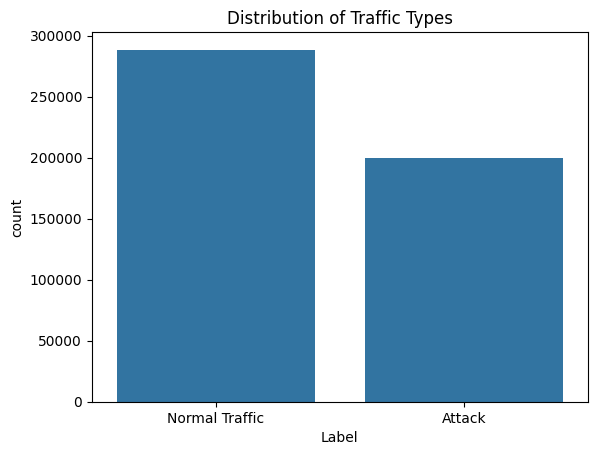

In [28]:
#Bar Chart
sns.countplot(x = 'Label',data = new_df)
plt.title("Distribution of Traffic Types")
plt.show()

In [29]:
#Count the number of occurences of each category(Normal Traffic and Attack)
new_df['Label'].value_counts()

Label
Normal Traffic    288548
Attack            199531
Name: count, dtype: int64

In [30]:
#Calculate average values
average_values = new_df.groupby('Label')[['Flow Duration','Packet Length Mean']].mean()
average_values

,Flow Duration,Packet Length Mean
Label,,
Attack,8.909046e+06,85.573255
Normal Traffic,8.966348e+06,85.542480


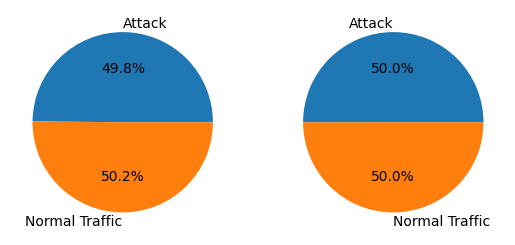

In [31]:
#pie chart for flow duration and packet length mean
average_values[['Flow Duration', 'Packet Length Mean']].plot(
    kind='pie',
    subplots=True,
    legend=False,
    autopct='%1.1f%%'
)

plt.show()

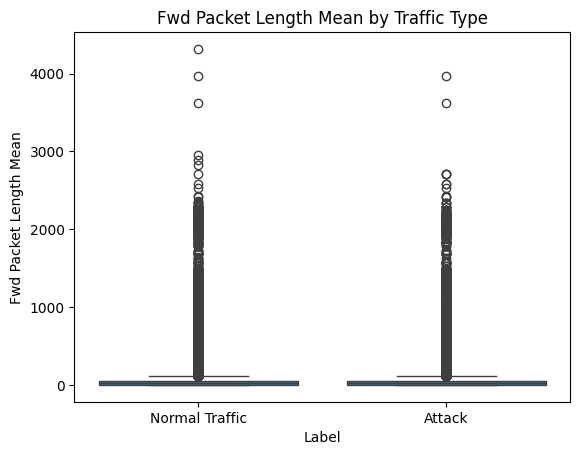

In [32]:
#Create box plot
sns.boxplot(x = 'Label',y = 'Fwd Packet Length Mean',data =new_df)
plt.title("Fwd Packet Length Mean by Traffic Type")
plt.show()

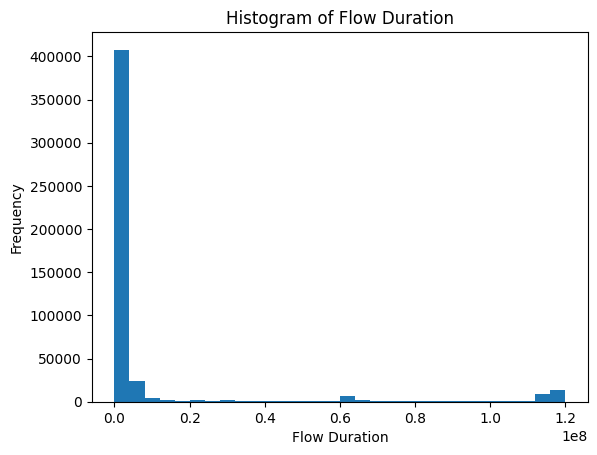

In [ ]:
# histogram diagram of flow duration
plt.hist(new_df['Flow Duration'], bins=30)
plt.title('Histogram of Flow Duration')
plt.xlabel('Flow Duration')
plt.ylabel('Frequency')
plt.show()

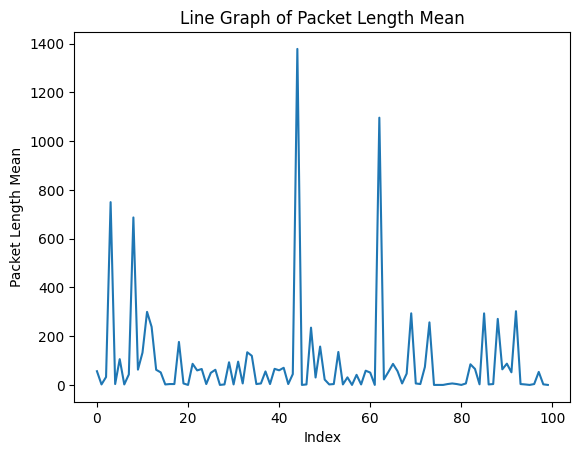

In [44]:
#line graph of packet length mean
plt.plot(new_df['Packet Length Mean'].head(100))
plt.title('Line Graph of Packet Length Mean')
plt.xlabel('Index')
plt.ylabel('Packet Length Mean')

plt.show()

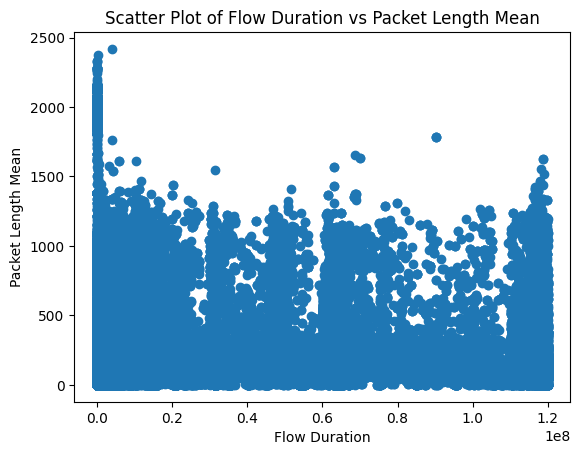

In [46]:
#scatter plot of flow duration and packet length mean
plt.scatter(new_df['Flow Duration'], new_df['Packet Length Mean'])
plt.title('Scatter Plot of Flow Duration vs Packet Length Mean')
plt.xlabel('Flow Duration')
plt.ylabel('Packet Length Mean')

plt.show()

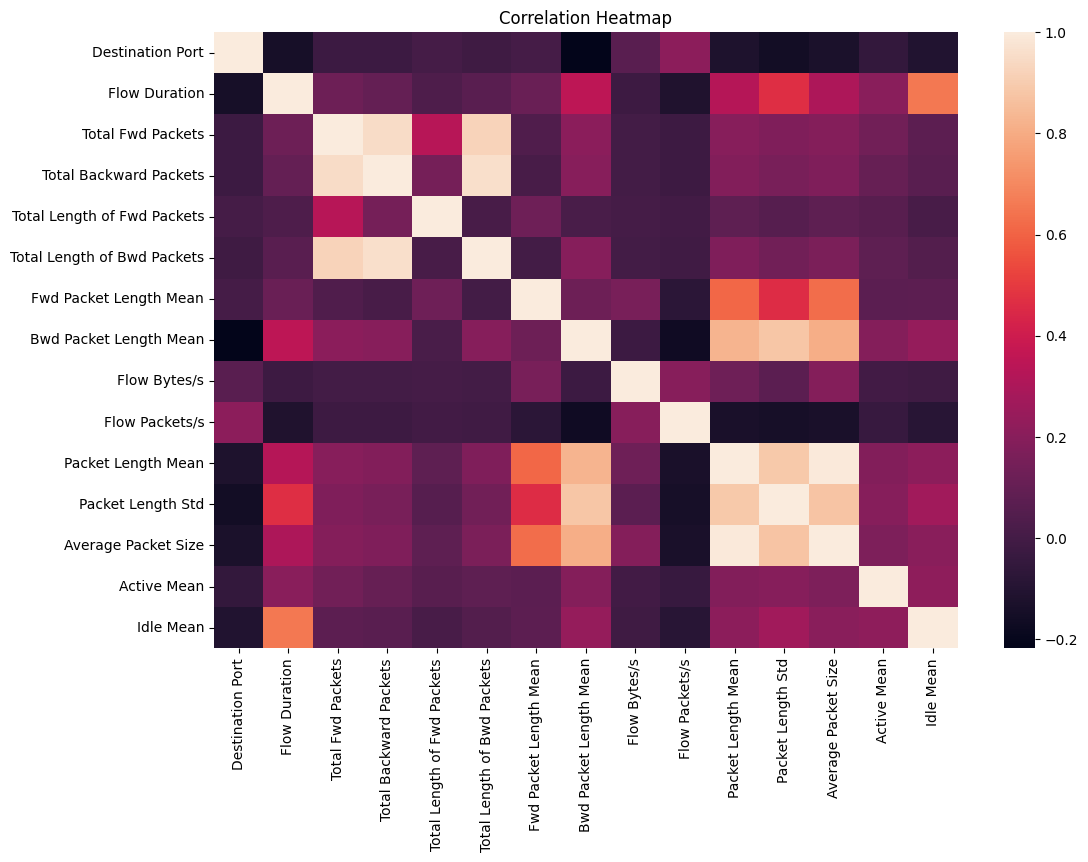

In [40]:
#Create a heatmap of the correlation matrix
correlation_matrix = new_df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix)
plt.title('Correlation Heatmap')
plt.show()

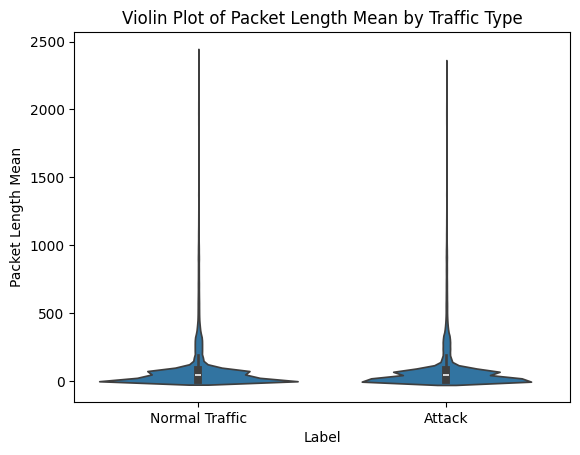

In [ ]:
#Create a violin plot
sns.violinplot(x='Label', y='Packet Length Mean', data=new_df)
plt.title('Violin Plot of Packet Length Mean by Traffic Type')
plt.show()

In [37]:

from scipy.stats import t

# split data
normal = new_df[new_df['Label'] == 'Normal Traffic']['Flow Duration']
attack = new_df[new_df['Label'] == 'Attack']['Flow Duration']

n1, n2 = len(normal), len(attack)
m1, m2 = normal.mean(), attack.mean()
s1, s2 = normal.std(ddof=1), attack.std(ddof=1)

# calculate t-score
t_score = (m1 - m2) / np.sqrt((s1**2 / n1) + (s2**2 / n2))

# critical value
df = n1 + n2 - 2
critical = t.ppf(1 - 0.05/2, df)

# print results
print("t-score:", t_score)
print("critical value:", critical)

if abs(t_score) > critical:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

t-score: 0.7166329663217962
critical value: 1.9599688449965256
Accept Null Hypothesis
